In [1]:
import numpy as np
data = np.load("../../../simulated_data/001-gridrobot/data/gridrobot_1960.npz")
all_trajs = data["trajs"]
all_feats = data["features"]

In [7]:
from sklearn import manifold
from matplotlib import ticker
import matplotlib.pyplot as plt

t_sne = manifold.TSNE(
    n_components=2,
    perplexity=30,
    init="random",
    max_iter=250,
    random_state=0,
)

def plot_2d(points, points_color, title):
    fig, ax = plt.subplots(figsize=(3, 3), facecolor="white", constrained_layout=True)
    fig.suptitle(title, size=16)
    add_2d_scatter(ax, points, points_color)
    plt.show()

def add_2d_scatter(ax, points, points_color, title=None):
    x, y = points.T
    ax.scatter(x, y, c=points_color, s=50, alpha=0.8)
    ax.set_title(title)
    ax.xaxis.set_major_formatter(ticker.NullFormatter())
    ax.yaxis.set_major_formatter(ticker.NullFormatter())

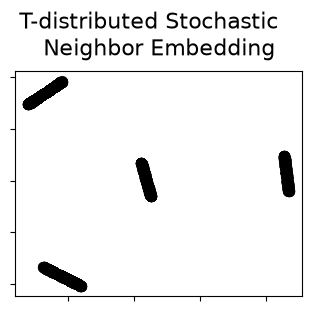

In [8]:
trajs_t_sne = t_sne.fit_transform(all_trajs)
plot_2d(trajs_t_sne, "black", "T-distributed Stochastic  \n Neighbor Embedding")


In [9]:
from sklearn.manifold import TSNE
import plotly.express as px

t_sne = TSNE(
    n_components=2,
    random_state=0,
)
trajs_t_sne = t_sne.fit_transform(all_trajs)

fig = px.scatter(
    trajs_t_sne , x=0, y=1
)
fig.show()

------ Agent MDP ------
num X :  5
num Y :  5
obstacles :  0
-----------------------


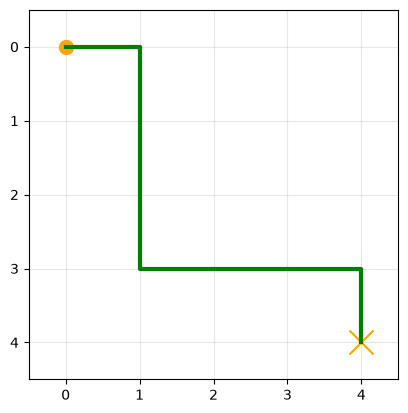

In [10]:
# TODO function to visualize a gridrobot trajectory would be great
import sys
sys.path.insert(0, '../../../simulated_data/001-gridrobot/')
from gridrobot import Gridrobot
    
config = {
    "X": 5,
    "Y": 5,
    "obstacles": [],
    "starts": [[0, 0], [0, 4], [4, 0], [4, 4]],
    "goals": [[4, 4], [4, 0], [0, 4], [0, 0]],
    "features": ["computer_dist", "joint_up"],
    "thetas": [[ -10.0, -10.0 ],
              [ 0.0, -10.0 ],
              [ 10.0, -10.0 ],
              [ -10.0, 0.0 ],
              [ 10.0, 0.0 ],
              [ -10.0, 10.0 ],
              [ 0.0, 10.0 ],
              [ 10.0, 10.0 ]
    ],
    "beta": 10.0,
    "feature_scaling": "normalize",
    "train_test_split": 0.8
}
env = Gridrobot(config["X"], config["Y"], config["obstacles"], config["starts"], config["goals"])
env.visualize_one_traj(all_trajs[0])